#AI-Powered Resume Screening & Candidate Ranking System

In [ ]:
!pip install PyPDF2 scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 6.0 MB/s eta 0:00:00


In [ ]:
!pip install PyPDF2 pandas matplotlib scikit-learn sentence-transformers

Saving Sailu_Test_Resume.pdf to Sailu_Test_Resume (7).pdf


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


========== ATS RANKING ==========

------------------------------------
Rank: 1
Candidate: Sailu_Test_Resume (7).pdf
Email: sailaja@example.com
Phone: +91-9876543210
ATS Score: 68.86000061035156
Skill Match: 75.0
Text Similarity: 54.529998779296875
Rating: Good
Recommendation: Recommended
Missing Skills: docker, aws

Resume Improvement Suggestions:
- Add docker projects or certifications
- Add aws projects or certifications
------------------------------------

Final Ranking Table:



,Rank,Candidate,ATS Score,Rating,Recommendation
0,1,Sailu_Test_Resume (7).pdf,68.860001,Good,Recommended


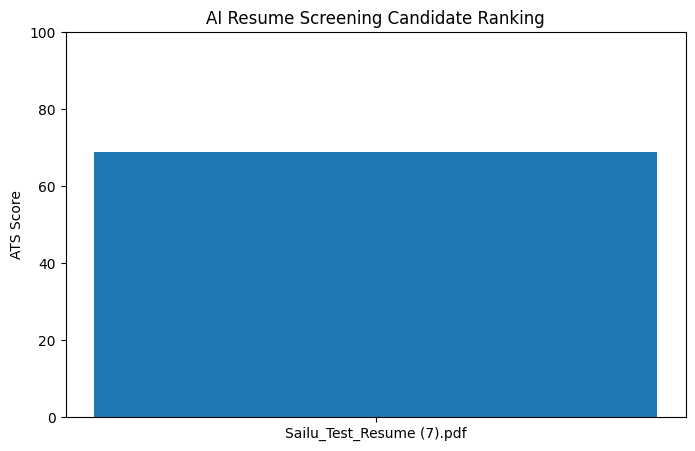

In [ ]:
from google.colab import files
uploaded = files.upload()

import PyPDF2
import pandas as pd
import matplotlib.pyplot as plt
import re

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
# ==========================
# JOB DESCRIPTION
# ==========================
model = SentenceTransformer('all-MiniLM-L6-v2')
job_description = """
We are looking for a Machine Learning Intern.

Required Skills:
Python
Machine Learning
Deep Learning
TensorFlow
SQL
Git
AWS
Docker

Responsibilities:
Build machine learning models, analyze data,
develop AI solutions, and collaborate with teams.
"""

# ==========================
# SKILL DATABASE
# ==========================

skills = [
    "python",
    "java",
    "c++",
    "machine learning",
    "deep learning",
    "tensorflow",
    "pytorch",
    "sql",
    "excel",
    "power bi",
    "tableau",
    "aws",
    "docker",
    "git",
    "html",
    "css",
    "javascript",
    "react",
    "data analysis"
]

# ==========================
# PDF TEXT EXTRACTION
# ==========================

def extract_text_from_pdf(pdf_file):
    text = ""

    with open(pdf_file, "rb") as file:
        reader = PyPDF2.PdfReader(file)

        for page in reader.pages:
            page_text = page.extract_text()

            if page_text:
                text += page_text

    return text

# ==========================
# PROCESS RESUMES
# ==========================

results = []

for filename in uploaded.keys():

    resume_text = extract_text_from_pdf(filename)

    # ----------------------
    # Email Extraction
    # ----------------------

    email = re.findall(
        r'[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}',
        resume_text
    )

    # ----------------------
    # Phone Extraction
    # ----------------------

    phone = re.findall(
        r'\+?\d[\d\s\-]{8,}\d',
        resume_text
    )

    # ----------------------
    # Text Similarity
    # ----------------------

    resume_embedding = model.encode([resume_text])

    jd_embedding = model.encode([job_description])

    similarity_score = cosine_similarity(
    resume_embedding,
    jd_embedding)[0][0] * 100

    # ----------------------
    # Skill Extraction
    # ----------------------

    resume_lower = resume_text.lower()
    jd_lower = job_description.lower()

    resume_skills = []
    jd_skills = []

    for skill in skills:

        if skill in resume_lower:
            resume_skills.append(skill)

        if skill in jd_lower:
            jd_skills.append(skill)

    matching_skills = list(
        set(resume_skills) & set(jd_skills)
    )

    missing_skills = list(
        set(jd_skills) - set(resume_skills)
    )

    # ----------------------
    # Skill Match Score
    # ----------------------

    skill_match_score = (
        len(matching_skills) /
        len(jd_skills)
    ) * 100

    # ----------------------
    # Final ATS Score
    # ----------------------

    final_score = (
    similarity_score * 0.3 +
    skill_match_score * 0.7
)

    # ----------------------
    # ATS Rating
    # ----------------------

    if final_score >= 80:
       rating = "Excellent"
    elif final_score >= 65:
       rating = "Good"
    elif final_score >= 50:
       rating = "Average"
    else:
       rating = "Poor"

    # ----------------------
    # Recommendation
    # ----------------------

    if final_score >= 80:
        recommendation = "Strongly Recommended"

    elif final_score >= 65:
        recommendation = "Recommended"

    else:
        recommendation = "Not Recommended"

    results.append({
        "Candidate": filename,
        "Email": email[0] if email else "Not Found",
        "Phone": phone[0] if phone else "Not Found",
        "ATS Score": round(final_score, 2),
        "Skill Match": round(skill_match_score, 2),
        "Text Similarity": round(similarity_score, 2),
        "Rating": rating,
        "Recommendation": recommendation,
        "Missing Skills": ", ".join(missing_skills)
    })

# ==========================
# CREATE RANKING
# ==========================

df = pd.DataFrame(results)

df = df.sort_values(
    by="ATS Score",
    ascending=False
)

df["Rank"] = range(1, len(df)+1)

# ==========================
# DISPLAY RESULTS
# ==========================

print("\n========== ATS RANKING ==========\n")

for _, row in df.iterrows():

    print("------------------------------------")
    print("Rank:", row["Rank"])
    print("Candidate:", row["Candidate"])
    print("Email:", row["Email"])
    print("Phone:", row["Phone"])
    print("ATS Score:", row["ATS Score"])
    print("Skill Match:", row["Skill Match"])
    print("Text Similarity:", row["Text Similarity"])
    print("Rating:", row["Rating"])
    print("Recommendation:", row["Recommendation"])
    print("Missing Skills:", row["Missing Skills"])
    if row["Missing Skills"]:
       print("\nResume Improvement Suggestions:")

    for skill in row["Missing Skills"].split(","):
        if skill.strip():
            print(f"- Add {skill.strip()} projects or certifications")
    print("------------------------------------")

# ==========================
# SHOW TABLE
# ==========================

print("\nFinal Ranking Table:\n")

display(
    df[
        [
            "Rank",
            "Candidate",
            "ATS Score",
            "Rating",
            "Recommendation"
        ]
    ]
)

# ==========================
# CHART
# ==========================

plt.figure(figsize=(8,5))

plt.bar(
    df["Candidate"],
    df["ATS Score"]
)

plt.ylim(0,100)

plt.ylabel("ATS Score")

plt.title(
    "AI Resume Screening Candidate Ranking"
)

plt.show()